In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
from matplotlib import pyplot as plt 
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns' , None)
pd.options.display.float_format = '{:20.2f}'.format

In [6]:
from scipy.spatial.distance import cdist # cdist -> cross distance. Find distance between every points

class AgglomerativeClusteringCustom: 
    def __init__(self , n_clusters = 2 , linkage = "ward"): 
        self.n_clusters = n_clusters
        self.linkage = linkage
        self.labels_ = None 
        self.children_ = [] # record the merges. 
    
    def fit_predict(self , X):
        n = X.shape[0] # number of rows
        clusters = [[i] for i in range(n)] # initially every point(index) in it's own cluster

        # continue merging until only n_clusters remain 
        while len(clusters) > self.n_clusters: 
            min_dist = float("INF") # minimum distance between clusters(based on that we will merge a pair of cluster each time) 
            pair = None 

            # Find cluster to cluster distances
            for c1 in range(len(clusters)): 
                for c2 in range(c1 + 1 , len(clusters)): 
                    # get the distance between cluster-1 and cluster-2 
                    dist = self._cluster_distance(X , clusters[c1] , clusters[c2])
                    # take the minimum distance 
                    if dist < min_dist: 
                        min_dist = dist
                        pair = (c1 , c2)

            # now merge pair of 2 clusters 
            if pair is not None:
                c1 , c2 = pair
                # merge c2 with c1 
                clusters[c1] = clusters[c1] + clusters[c2]
                self.children_.append([c1 , c2])
                # remove cluster c2
                del clusters[c2]

        # now assign each point with it's clusters 
        self.labels_ = np.zeros(shape = n , dtype = int)

        for cluster_id , members in enumerate(clusters): 
            for m in members: 
                self.labels_[m] = cluster_id

        return self.labels_

    def _cluster_distance(self , X , cluster1 , cluster2):
        # find the distance between all the pair points of cluster1 and cluster2
        distances = cdist(X[cluster1] , X[cluster2] , metric = "euclidean")

        if self.linkage == "single": 
            return np.min(distances)
        elif self.linkage == "complete": 
            return np.max(distances)
        elif self.linkage == "average":
            return np.mean(distances)
        elif self.linkage == "ward": 
            # minimize the variance increases SSE
            merged = np.vstack((X[cluster1] , X[cluster2]))
            centroid = np.mean(merged , axis = 0)
            return np.sum((merged - centroid) ** 2)
        else:
            raise ValueError(f"Unknown linkage: {self.linkage}")

In [9]:
X = np.array([
    [1, 2], [1.5, 1.8], [5, 8], [7,8] , [2.5 , 2],
    [8, 8], [1, 0.6], [9, 11] , [5,6] , [8.5,8.2]
])

for method in ["single", "complete", "average", "ward"]:
    model = AgglomerativeClusteringCustom(n_clusters = 2 , linkage = method)
    labels = model.fit_predict(X)
    print(f"Linkage={method}, Labels={model.labels_}")
    print("Merge history:", model.children_)
    print()

Linkage=single, Labels=[0 0 1 1 0 1 0 1 1 1]
Merge history: [[5, 9], [0, 1], [2, 4], [0, 3], [0, 3], [1, 2], [1, 3], [1, 2]]

Linkage=complete, Labels=[0 0 1 1 0 1 0 1 1 1]
Merge history: [[5, 9], [0, 1], [0, 5], [2, 4], [1, 5], [0, 3], [2, 3], [1, 2]]

Linkage=average, Labels=[0 0 1 1 0 1 0 1 1 1]
Merge history: [[5, 9], [0, 1], [2, 4], [0, 3], [0, 3], [1, 4], [1, 2], [1, 2]]

Linkage=ward, Labels=[0 0 1 1 0 1 0 1 1 1]
Merge history: [[5, 9], [0, 1], [2, 4], [0, 3], [1, 5], [0, 3], [2, 3], [1, 2]]



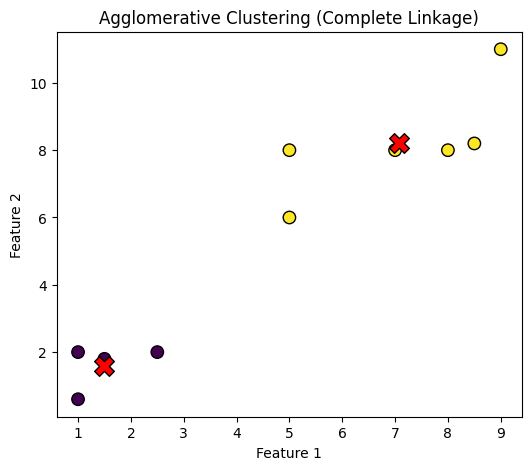

In [10]:
plt.figure(figsize=(6, 5))


plt.scatter(X[ : , 0] , X[ : , 1] , c = labels , cmap = "viridis" , s = 80 , edgecolor = "k")

# optional: mark centroids
for cluster_id in np.unique(labels):
    centroid = X[labels == cluster_id].mean(axis = 0)
    plt.scatter(*centroid , c = "red" , marker = "X" , s = 200, edgecolors = "black")

plt.title("Agglomerative Clustering (Complete Linkage)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()